In [2]:
import sys
sys.path.insert(0, '..')

In [ ]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [4]:
wid = 100
oversample = 4

nwavels = 7#13#6
npoly=1#10#2

n_zernikes = 20#30#12

optics = NICMOSSecondaryFresnelOptics(512, wid, oversample, mag=3.3, defocus=0., despace=0., n_zernikes = n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = "../data/MAST_2024-09-08T07_59_18.213Z/HST/"

files = [
    # F095N
    "n43ca5fjq_cal.fits",
    "n43ca5fkq_cal.fits",
    "n43ca5flq_cal.fits",
    "n43ca5fmq_cal.fits",
    #F190N
    "n43ca5feq_cal.fits",
    "n43ca5ffq_cal.fits",
    "n43ca5fgq_cal.fits",
    "n43ca5fhq_cal.fits",
    #F187N
    #"n43c03dnq_cal.fits",
    #"n43c03doq_cal.fits",
    #"n43c03dpq_cal.fits",
    #"n43c03drq_cal.fits",
    #F108N
    #"n43c03dsq_cal.fits",
    #"n43c03duq_cal.fits",
    ##"n43c03dvq_cal.fits",
    ##"n43c03dwq_cal.fits",
][-1:]

exposures_single = [
    exposure_from_file(ddir + "n43ca5fhq_cal.fits", PointSourceContrastFit(spectrum_basis, "F190N"), crop=wid),
    #exposure_from_file(ddir + "n43c03dsq_cal.fits", SinglePointFit(spectrum_basis, "F108N"), crop=wid),
    ]



W0528 15:02:09.939228 1584882 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Version 4.4.0
124 52


/Users/haydengreer/PhD/hst/hubble/notebooks/../models.py:176: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return Exposure(filename, name, filter, data, err_with_poisson, bad_with_poisson, fit, mjd, exptime, wcs, pam)


In [5]:
for e in exposures_single:
    print(e.mjd)#*86400)
    print(e.target)
    print(e.filter)
    print(e.exptime)

50934.93448622
SAO179809-PSF
F190N
19.93641


In [6]:
params = {
    #"fluxes": {},
    "positions": {},
    "spectrum": {},
    "aberrations": {},

    #"rot": 0.,

    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_scale": {},
    "cold_mask_shear": {},
    "primary_scale": {},
    "primary_rot": {},
    "primary_shear": {},
    "outer_radius": 1.2*0.955,
    "secondary_radius": 0.372*1.2,
    "spider_width": 0.077*1.2,

    "softening": 10.,
    "bias": {},
    "jitter": {},

    "defocus": {},
    "despace": {},
    "mag": 3.3,
    "quadrature": {},
    "secondary_spectrum": {},
    "secondary_position": {},
}

positions = [[0.,0.,],[0.,0.,],[0.,0.,],[0.,0.,]]#[[0.43251792, 0.33013815],[ 0.49417186, -0.5629123 ]]


for idx, exp in enumerate(exposures_single):
    params["positions"][exp.fit.get_key(exp, "positions")] = np.asarray([0.,0.])
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels))
    params["secondary_spectrum"][exp.fit.get_key(exp, "secondary_spectrum")] = (np.zeros(npoly)).at[0].set(1e-8)
    params["secondary_position"][exp.fit.get_key(exp, "secondary_position")] = np.asarray([0.,0.])

    params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.zeros(n_zernikes)

    # params["aberrations"][exp.fit.get_key(exp, "aberrations")] = np.asarray([ 21.9267203 , -14.20133333, -27.77798078, -28.44491861,
    #       -5.48501933,  -8.87418317,  23.78868922,   7.46177568,
    #       -0.2863787 , -13.39340241,  -4.89880687,   4.25452262,
    #       -4.49137758,   3.42268926,   4.09896897,  -3.15079696,
    #        1.90339653,  -5.20437772,   5.11727282,   1.82359044])#np.zeros(n_zernikes)#np.asarray([0., 24.884588  , -25.489779  , -17.15699   , -21.790146  ,
    #      -4.592212  ,  -4.832893  ,  19.196083  ,   0.37983412,
    #       7.0756216 ,   0.30277824,  -6.330534])#np.zeros(n_zernikes)
    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.asarray([8.,8.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = -45.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.,0.])
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -45. + 90. 
    params["primary_scale"][exp.fit.get_key(exp, "primary_scale")] = np.asarray([1.,1.])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])
    params["defocus"][exp.fit.get_key(exp, "defocus")] = 0.
    params["despace"][exp.fit.get_key(exp, "despace")] = 0.#-5.#0.
    

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    params["jitter"][exp.fit.get_key(exp, "jitter")] = 7/43*oversample

    params["quadrature"][exp.fit.get_key(exp, "quadrature")] = np.array(0.)


model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))
#model_binary = set_array(NICMOSModel(exposures_binary, params, optics, detector))


params = ModelParams(params)

13.13069974608145


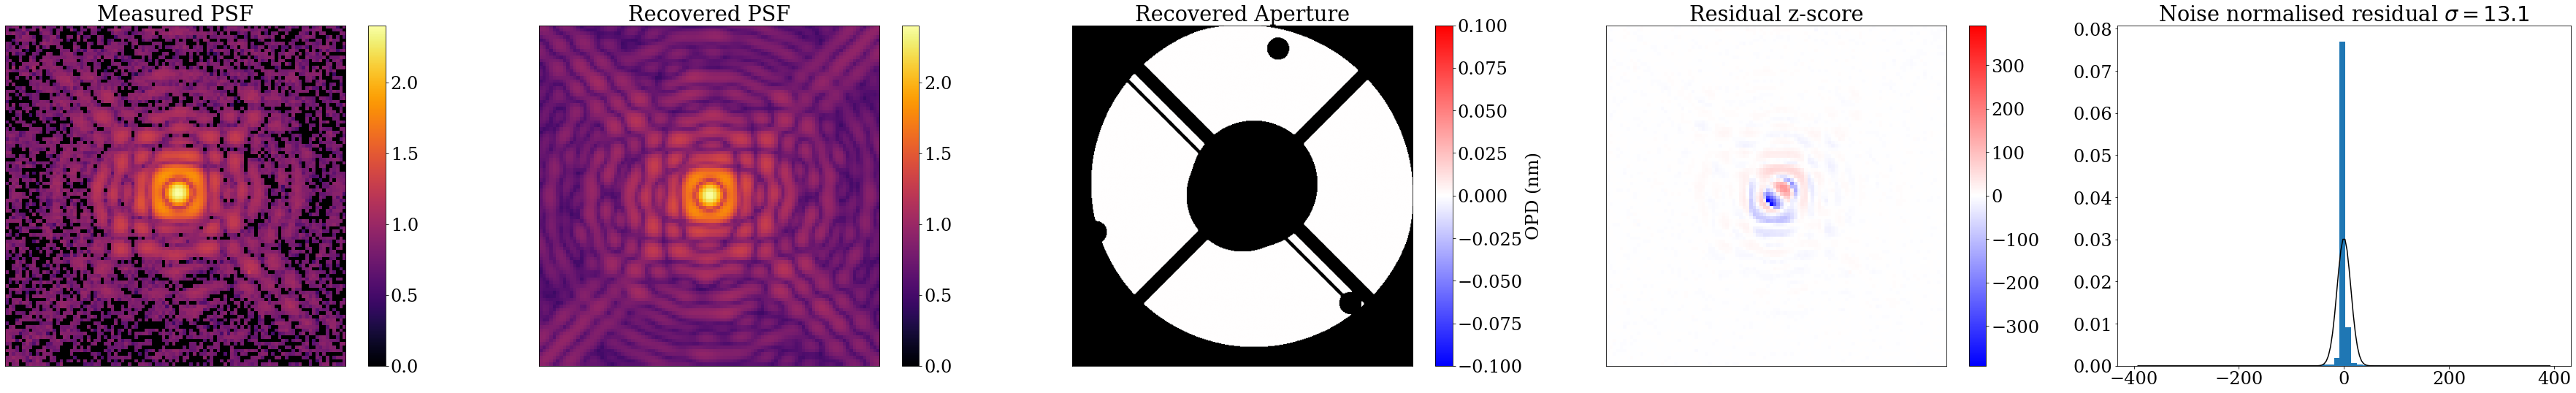

In [7]:
plot_comparison(model_single, params, exposures_single)

In [8]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)


g = 5e-2

things = {
    "positions": sgd(g*2.5, 0),
    "spectrum": sgd(g*3, 10),
    "cold_mask_shift": sgd(g*5, 30),
    
    "bias": sgd(g*3, 20),
    "aberrations": sgd(g*2, 70),
    #"jitter": opt(g*1, 120),

    "despace": sgd(g*5, 50),
    "mag": sgd(g*3, 100),

    "cold_mask_shear": sgd(g*0.2, 100),

    "quadrature": sgd(g*20, 450)
}

things_start = {
    "positions": sgd(g*5, 0),
}

groups = list(things.keys())

In [9]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [10]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things_start, 10)

  0%|          | 0/10 [00:00<?, ?it/s]

4.024202751804968


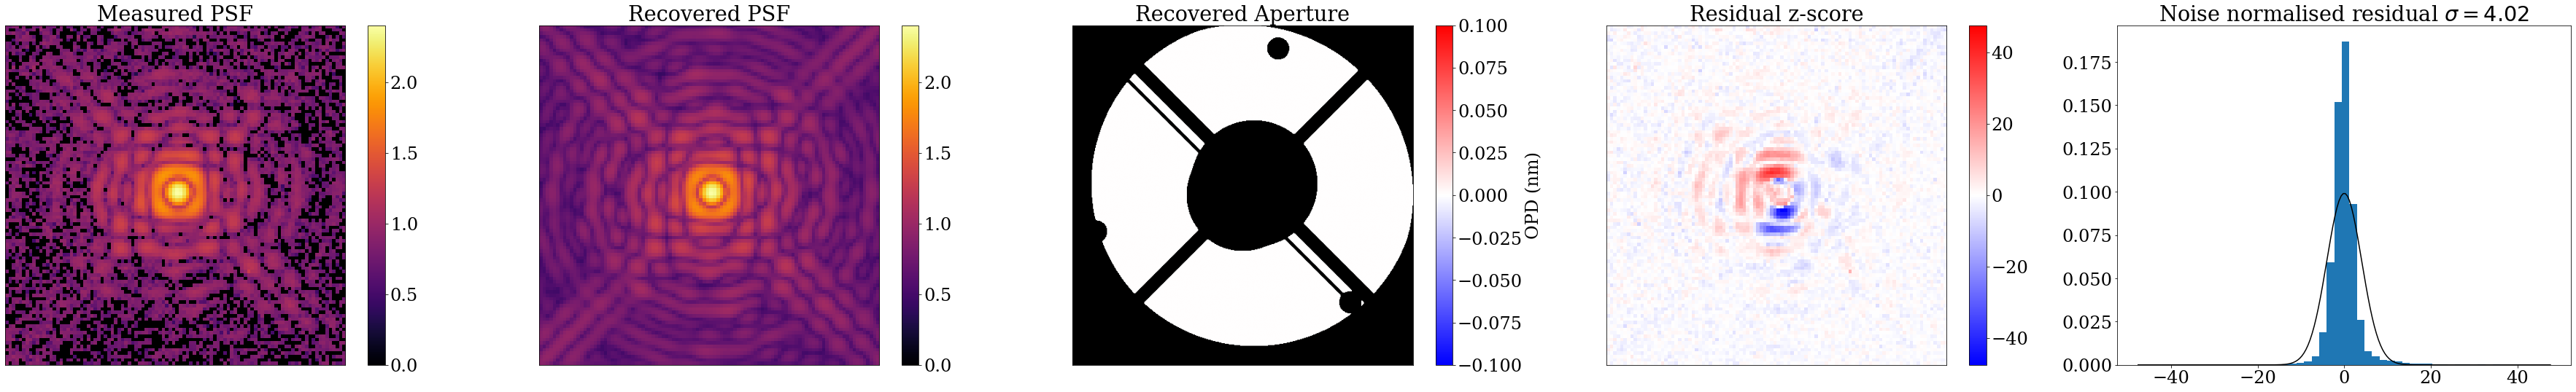

In [11]:
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single)

In [12]:
params_history

[{'positions': {'n43ca5fhq': Array([0., 0.], dtype=float64)}},
 {'positions': {'n43ca5fhq': Array([-0.1965461 , -0.19283523], dtype=float64)}},
 {'positions': {'n43ca5fhq': Array([-0.37222273, -0.36599237], dtype=float64)}},
 {'positions': {'n43ca5fhq': Array([-0.50276423, -0.49619178], dtype=float64)}},
 {'positions': {'n43ca5fhq': Array([-0.59068184, -0.58569411], dtype=float64)}},
 {'positions': {'n43ca5fhq': Array([-0.64544846, -0.64323181], dtype=float64)}},
 {'positions': {'n43ca5fhq': Array([-0.67661137, -0.67761743], dtype=float64)}},
 {'positions': {'n43ca5fhq': Array([-0.69201577, -0.69616062], dtype=float64)}},
 {'positions': {'n43ca5fhq': Array([-0.69758326, -0.70447129], dtype=float64)}},
 {'positions': {'n43ca5fhq': Array([-0.69752231, -0.70662617], dtype=float64)}}]

In [13]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [14]:
losses, params_history = optimise_new(opt_params, model_single, exposures_single, things, 500)

  0%|          | 0/500 [00:00<?, ?it/s]

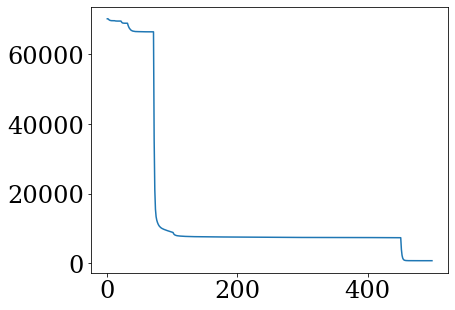

In [15]:
plt.plot(losses[:])

In [16]:
losses[-1]

Array(739.98380209, dtype=float64)

9
0.998145328939848


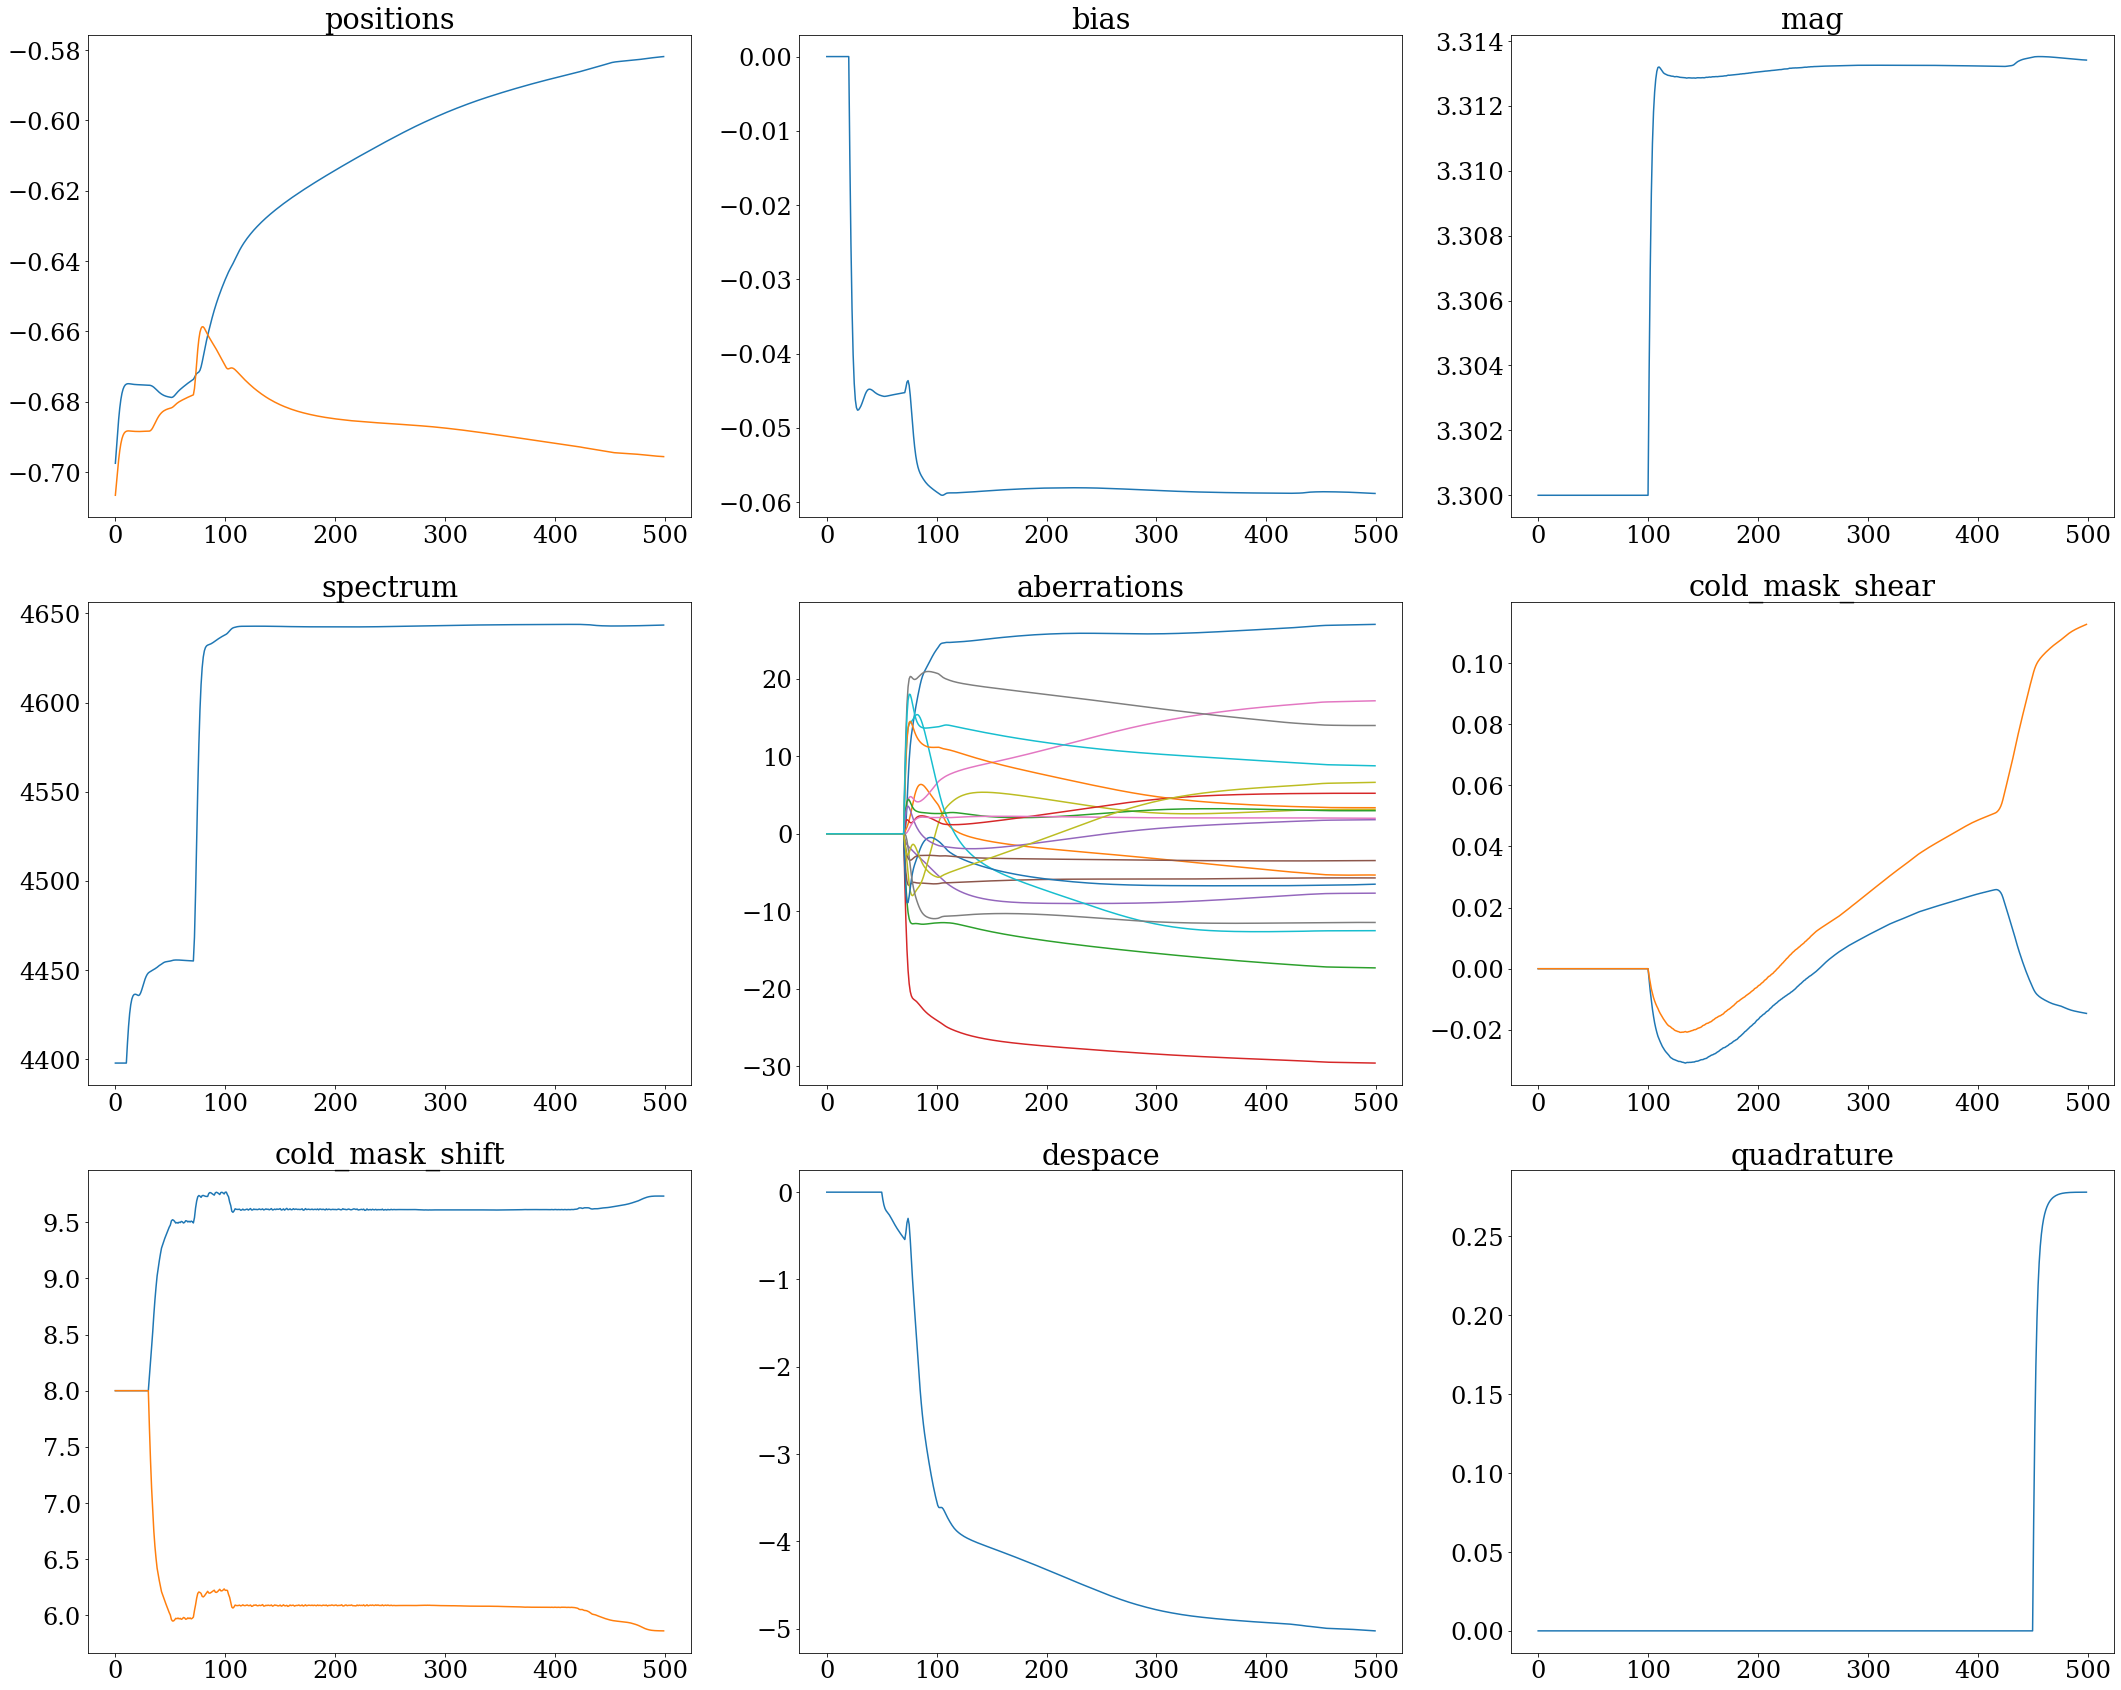

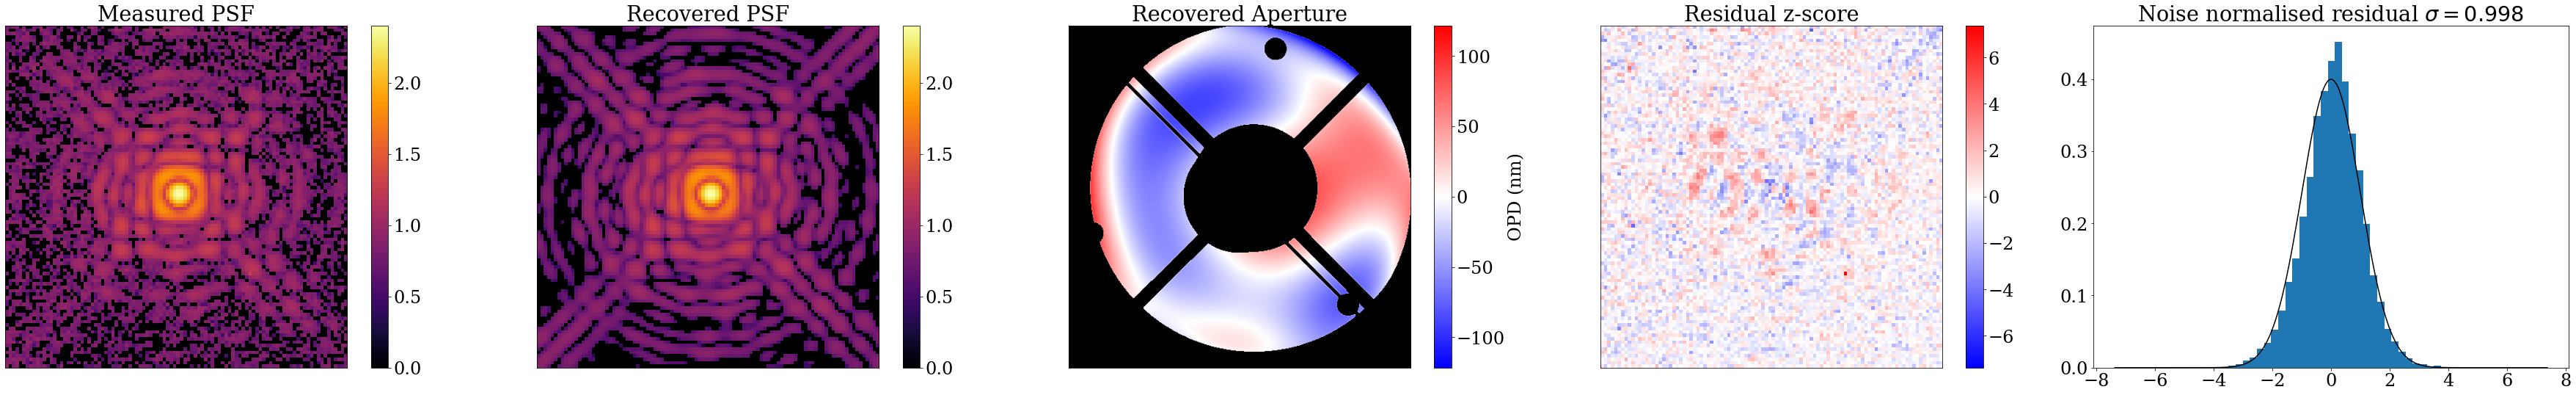

In [17]:
plot_params(params_history, groups, xw = 3)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=True)

In [18]:
final_params = ModelParams(params_history[-1])

In [19]:
final_params.params

{'aberrations': {'n43ca5fhq': Array([ 27.03990397,  -5.32049366, -17.30388889, -29.59208001,
          -7.65995766,  -5.69246672,  17.17433503,  13.98511308,
           3.15483095, -12.50167076,  -6.5007686 ,   3.37218751,
           2.98504917,   5.23594022,   1.82315174,  -3.45147739,
           2.00916311, -11.44055351,   6.64689442,   8.78228535],      dtype=float64)},
 'bias': {'n43ca5fhq': Array(-0.05883129, dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.01463058,  0.11269905], dtype=float64)},
 'cold_mask_shift': {'global': Array([9.73285397, 5.86128619], dtype=float64)},
 'despace': {'n43ca5fhq': Array(-5.02549969, dtype=float64)},
 'mag': Array(3.31341061, dtype=float64),
 'positions': {'n43ca5fhq': Array([-0.58182111, -0.69563263], dtype=float64)},
 'quadrature': {'n43ca5fhq': Array(0.27808021, dtype=float64)},
 'spectrum': {'SAO179809-PSF_F190N': Array([4643.48203992], dtype=float64)}}

In [20]:
final_params.params["spectrum"]["SAO179809-PSF_F190N"]

Array([4643.48203992], dtype=float64)

In [21]:
ns = 64
lim = 32

X, Y = np.meshgrid(np.linspace(-lim, lim, ns), np.linspace(-lim, lim, ns))
X = X.flatten()
Y = Y.flatten()

In [22]:
prms = params.params | final_params.params | {
        'secondary_spectrum': {'SAO179809-PSF_F190N': np.array([2e1])},
        'secondary_position': {'SAO179809-PSF_F190N': np.array((0.,0.,))}
    }

In [23]:
np.vstack([X,Y]).T.shape

(4096, 2)

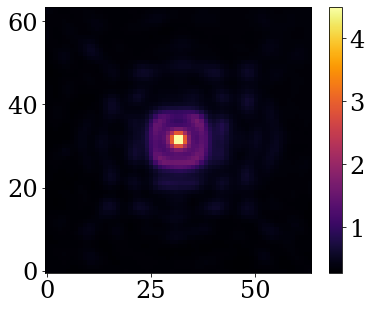

In [24]:
ppos = final_params.params["positions"]["n43ca5fhq"]

def loss_fn(flux, position):
    prms = params.params | final_params.params | {
        'secondary_spectrum': {'SAO179809-PSF_F190N': np.array([flux])},
        'secondary_position': {'SAO179809-PSF_F190N': np.array(position)+ppos}
    }
    

    mdl = ModelParams(prms).inject(model_single)
    return np.nansum(np.asarray([posterior(mdl,exposure) for exposure in exposures_single]))

@jax.jit
def cl(x, y):
    return 1/np.sqrt(jax.hessian(lambda f: loss_fn(f, (x,y)))(1e-3))

# limits = np.zeros((ns*ns))

# for i in tqdm(range(ns**2)):
#     x, y = X[i], Y[i]
#     limits = limits.at[i].set(cl(x,y))


limits = jax.lax.map(lambda a: cl(a[0], a[1]), np.vstack([X,Y]).T, batch_size=64)

plt.imshow(limits.reshape((ns,ns)))
plt.colorbar()

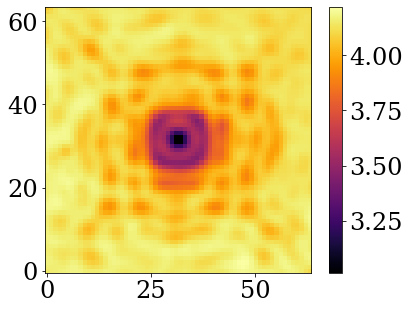

In [25]:
plt.imshow(np.log10(4650/limits.reshape((ns,ns))))
plt.colorbar()

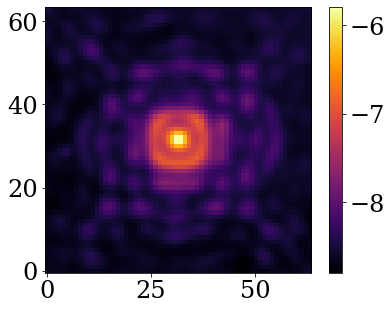

In [26]:
plt.imshow(-2.5*np.log10(4650/5/limits.reshape((ns,ns))))
plt.colorbar()

Text(0.5, 0, 'Separation (mas)')

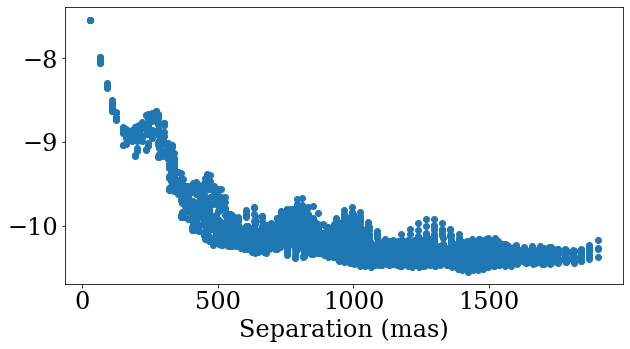

In [27]:
plt.figure(figsize=(10,5))
plt.scatter(np.sqrt(X**2+Y**2)*42, -2.5*np.log10(1+4650/limits))
plt.xlabel("Separation (mas)")

In [28]:
nbins = 50
seps = np.sqrt(X**2+Y**2)*42
edges = np.linspace(0, np.max(seps), nbins+1)
bins = (edges[1:]+edges[:-1])/2
bv = np.zeros(nbins)
br = np.zeros(nbins)

for i in range(nbins):
    bin_vals = -2.5*np.log10(final_params.params["spectrum"]["SAO179809-PSF_F190N"]/limits[(seps >= edges[i]) & (seps < edges[i+1])]/5)

    bv = bv.at[i].set(np.mean(bin_vals))
    br = br.at[i].set(np.std(bin_vals))

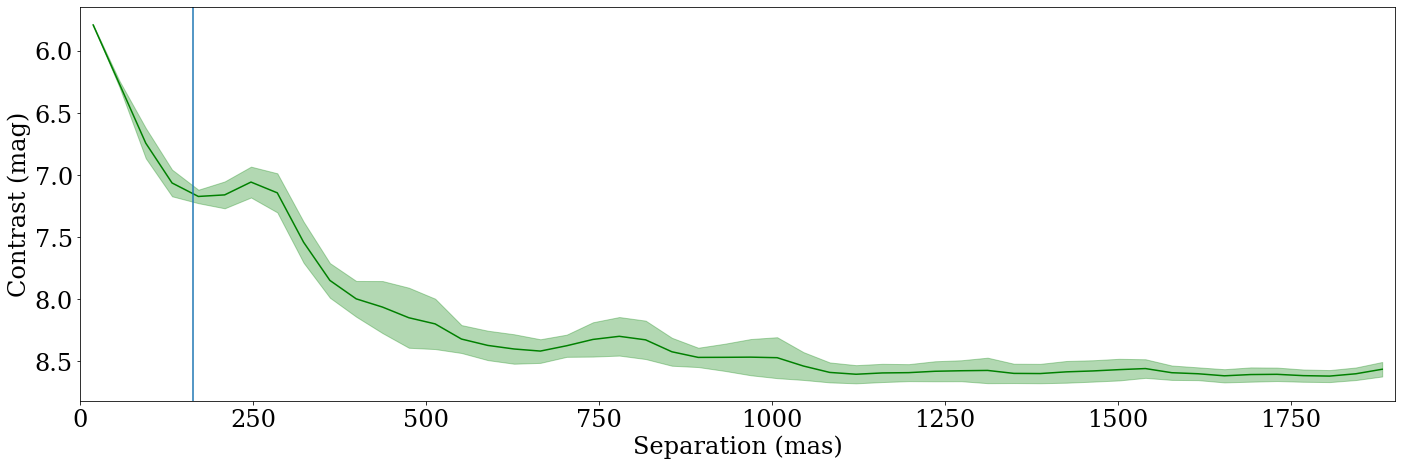

In [29]:
plt.figure(figsize=(20, 7))
plt.plot(bins, bv, color='green')
plt.xlabel("Separation (mas)")
plt.ylabel("Contrast (mag)")
plt.yticks([-6.0, -6.5, -7, -7.5, -8, -8.5], labels=["6.0", "6.5", "7.0", "7.5", "8.0", "8.5"])
plt.axvline(dlu.rad2arcsec(1.9e-6/2.4)*1000)
plt.xlim(edges[0], edges[-1])
plt.fill_between(
    bins,
    bv - br,
    bv + br,
    color='green',
    alpha=0.3
)
plt.tight_layout()
plt.savefig("contrast.pdf")

In [30]:
params.params | final_params.params

{'positions': {'n43ca5fhq': Array([-0.58182111, -0.69563263], dtype=float64)},
 'spectrum': {'SAO179809-PSF_F190N': Array([4643.48203992], dtype=float64)},
 'aberrations': {'n43ca5fhq': Array([ 27.03990397,  -5.32049366, -17.30388889, -29.59208001,
          -7.65995766,  -5.69246672,  17.17433503,  13.98511308,
           3.15483095, -12.50167076,  -6.5007686 ,   3.37218751,
           2.98504917,   5.23594022,   1.82315174,  -3.45147739,
           2.00916311, -11.44055351,   6.64689442,   8.78228535],      dtype=float64)},
 'cold_mask_shift': {'global': Array([9.73285397, 5.86128619], dtype=float64)},
 'cold_mask_rot': {'global': -45.0},
 'cold_mask_scale': {'global': Array([1., 1.], dtype=float64)},
 'cold_mask_shear': {'global': Array([-0.01463058,  0.11269905], dtype=float64)},
 'primary_scale': {'global': Array([1., 1.], dtype=float64)},
 'primary_rot': {'global': 45.0},
 'primary_shear': {'global': Array([0., 0.], dtype=float64)},
 'outer_radius': 1.146,
 'secondary_radius': 0.

In [31]:
model = final_params.inject((model_single))

coords = dlu.pixel_coords(512, 2.4)
cropped_frame = exp.data**0.125

fit = exp.fit(model, exp)


In [32]:
psf_norm = fit/np.sum(fit)

In [33]:
np.roll(psf_norm, (0,1))

Array([[ 1.77616198e-05,  1.21551167e-05,  1.21034129e-05, ...,
        -1.65885438e-06,  7.08750898e-07,  5.42823622e-06],
       [ 9.21858998e-06,  1.27411064e-05,  1.74442247e-05, ...,
        -1.02389769e-06,  2.97630095e-06,  8.79315444e-06],
       [ 1.25046767e-05,  7.72539762e-06,  1.55085808e-05, ...,
         4.17872071e-07,  4.43283547e-06,  8.47457890e-06],
       ...,
       [ 2.50662267e-06, -7.89786271e-07,  1.08088545e-06, ...,
         1.50592863e-05,  1.84082039e-05,  1.60844056e-05],
       [ 1.00052686e-05,  2.85446900e-06,  5.69616243e-06, ...,
         7.43349390e-06,  1.45484285e-05,  1.82489716e-05],
       [ 1.65748813e-05,  7.16701622e-06,  1.00166366e-05, ...,
         9.10053340e-07,  7.33461766e-06,  1.42539438e-05]],      dtype=float64)

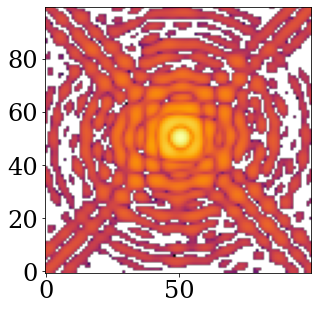

In [34]:
plt.imshow(np.log10(fit))

In [92]:
ns = 40
lims = np.zeros((2*ns, 2*ns))
for i in tqdm(range(-ns, ns)):
    for j in range(-ns, ns):
        lims = lims.at[i+ns,j+ns].set(1/np.sqrt(np.nansum(np.roll(np.roll(psf_norm, j, axis=1), i, axis=0)**2/(10**0.3 * exp.err))))#0.00003*0))))

  0%|          | 0/80 [00:00<?, ?it/s]

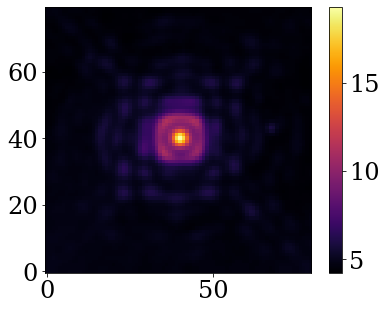

In [93]:
plt.imshow(lims)
plt.colorbar()

In [94]:
exposures_single[0].exptime

19.93641

In [95]:
lims

Array([[4.85027144, 4.85000253, 4.82467112, ..., 4.84432833, 4.87157072,
        4.8532832 ],
       [4.80462336, 4.82926339, 4.82929465, ..., 4.91400071, 4.94116956,
        4.89891768],
       [4.77158217, 4.81446995, 4.84322401, ..., 4.9490023 , 4.96184757,
        4.90013398],
       ...,
       [4.60385753, 4.59280462, 4.61852389, ..., 4.51127602, 4.48908752,
        4.47214898],
       [4.58783676, 4.63202394, 4.66767722, ..., 4.48465569, 4.4602586 ,
        4.4468336 ],
       [4.52879364, 4.61156139, 4.65450687, ..., 4.46132219, 4.45269864,
        4.45816414]], dtype=float64)

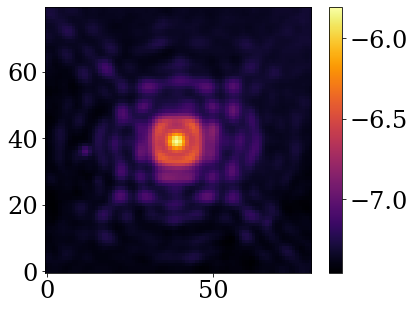

In [97]:
plt.imshow(-2.5*np.log10(4650/5/np.flip(lims)*np.sqrt(19)))
plt.colorbar()

In [ ]:
sigma_R_det = 7 # 4 photons on the real detector

det_pscale = 42e-3

oversample = det_pscale/pscale

sigma_R = sigma_R_det/oversample  # electrons RMS per pixel, for example

print(sigma_R)



denom = (flux) * psf + sigma_R**2



A = jsp.signal.correlate(psf**2, 1 / denom, mode="same")

B = jsp.signal.correlate(psf, psf / denom, mode="same")

C = np.sum(psf**2 / denom)



F_map = (flux)**2 * (A - 2 * B + C)


sigma = 5
contrast_readnoise = sigma / np.sqrt(F_map)